# Lab03：Temporal Pattern 決定 Detector

這個 Lab 只回答一個問題：

> 異常的 temporal pattern 不同時，應該選 Shewhart、EWMA 還是 CUSUM？

我們會從 rational subgroup、Phase I estimation 與 seasonality removal 開始，再用相同的 residual、相同的 calibration split 與相同的 false-signal budget 比較三種方法。

三個 monitoring scenarios：

1. **S1 — Large isolated spikes**：三個彼此分離的五分鐘極端值。
2. **S2 — Small persistent shift**：每一點不一定離譜，但持續朝同一方向偏移。
3. **S3 — Gradual drift**：近期 process state 逐步改變。

Notebook 內的說明與程式註解使用繁體中文；所有圖中文字使用英文，避免 matplotlib 中文字型問題。

## 模擬資料全貌：先知道實驗怎麼造

這是一份 **deterministic teaching simulation**。相同 seed 會產生相同資料；它的目的，是隔離 temporal pattern 對 detector 的影響，不代表真實網路流量的完整分布。

$$
Y_t=s(\text{day type},\text{time of day})+\epsilon_t+a_j(t),
\qquad \epsilon_t\sim\mathcal{N}(0,3^2)
$$

- $s$：平滑日週期；深夜約 15%、工作時段約 45%，週末約為平日的 60%。
- $\epsilon_t$：standard deviation 3 percentage points 的 Gaussian noise。
- $a_j(t)$：scenario $j$ 注入的異常。
- 每 5 分鐘一筆 uplink utilization。

| Data | 長度 | 責任 |
| --- | ---: | --- |
| estimate | 28 天 | 建立 seasonal profile、residual center 與 $\sigma_{MR}$ |
| calibration | 14 天 | 只調 false-signal sensitivity，不重新 fit |
| monitoring | 每個 scenario 7 天 | 套用 frozen model，比較 detector |

S1–S3 複製同一段正常 monitoring **共同背景**，只有注入事件不同，因此是 paired comparison：

| Scenario | 注入配方 |
| --- | --- |
| S1 | 03-04 10:00、03-06 14:00、03-08 10:00 各一個 $+4.5\sigma_{MR}$ spike |
| S2 | 03-04 09:00 起，$+0.8\sigma_{MR}$ 持續 36 小時 |
| S3 | 03-04 00:00 起，72 小時由 0 線性增加到 $+2.5\sigma_{MR}$，之後維持 |

Scenario table 本身沒有 label；event truth 放在獨立 events table。這裡公開配方，是因為本 Lab 的問題不是猜事件，而是：**已知 change mechanism 後，如何公平校準並選擇 detector？**

## 1. 公式很簡單，但 $\mu$ 與 $\sigma$ 從哪裡來？

Shewhart chart 的共同想法，是判斷某個監控統計量 $T$ 是否偏離正常中心：

$$
UCL_T=E[T]+3\operatorname{SD}(T),\qquad
LCL_T=E[T]-3\operatorname{SD}(T)
$$

實務上，我們不知道真正的 $\mu$ 與 $\sigma$，只能用可信的 Phase I reference data 估計 $\hat\mu$ 與 $\hat\sigma$。而且 limits 的 scale 取決於你監控的量：

| Monitoring statistic | Center | Standard deviation |
| --- | --- | --- |
| individual $X_t$ | $\mu$ | $\sigma$ |
| subgroup mean $\bar{X}_i$ | $\mu$ | $\sigma/\sqrt n$ |

所以 $\widehat{UCL}=\hat\mu+3\hat\sigma$ 是 individual observation 的 plug-in limit；$\bar{X}$ chart 監控 subgroup mean，必須使用 $\hat\sigma/\sqrt n$。接下來的 correction factors 不是為了把結果調漂亮，而是讓 sample statistics 能正確估計未知的 process scale。

In [1]:
from pathlib import Path
from math import gamma, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 20)

def find_repo_root(start: Path = Path.cwd()) -> Path:
    """從 Jupyter 啟動目錄向上尋找 repository root。"""
    resolved_start = start.resolve()
    for candidate in (resolved_start, *resolved_start.parents):
        if (candidate / "data" / "synthetic").is_dir():
            return candidate
    raise FileNotFoundError("找不到 data/synthetic；請從課程 repository 內開啟 notebook。")


ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "synthetic"
CADENCE_MINUTES = 5
SLOTS_PER_DAY = 288

## 2. 三段資料，三種責任

| Split | 可以做什麼 | 不可以做什麼 |
| --- | --- | --- |
| estimate | 學 seasonal profile、residual center、$\sigma_{MR}$ | 不看 monitoring event |
| calibration | 調整正常時願意接受的 false signal rate | 不重估 center 或 scale |
| monitoring | 套用已凍結的模型並評估 delay | 不重新 fit |

$$
\text{estimate}\rightarrow
(\widehat{s}_t,\mu_r,\sigma_{MR})
\rightarrow\text{calibration threshold}
\rightarrow\text{monitoring}
$$

Calibration 像 validation set：它仍然是正常資料，但用來決定 detector 多容易響。

## 3. Measurement 如何產生？先決定 $\bar{X}$-S 還是 I-MR

Rational subgroup 是在同一個 process state 下取得的一組 measurements。

- **$\bar{X}$-S 情境**：monitoring agent 每五分鐘對同一 endpoint 快速送出 5 次 latency probes。同一個 burst 的 5 筆 measurements 代表同一短時間、同一 process state，因此形成 rational subgroup。
- **I-MR 情境**：RRD 每五分鐘只保存一筆 port utilization。每個 timestamp 沒有 replicates，只形成一條 sequential individual series。

本 Lab 的正式 uplink utilization 使用 I-MR。先做 $\bar{X}$-S latency probes 小例子，是為了看懂「有意義的 subgroup」與 scale estimation；不能把連續五個 utilization timestamps 硬湊成 subgroup，因為它們可能跨越 process change。

### 3.1 $\bar{X}$-S 的數學

第 $i$ 組有 $n$ 筆：

$$
\bar{X}_i=\frac{1}{n}\sum_{j=1}^{n}X_{ij},
\qquad
S_i=\sqrt{\frac{1}{n-1}\sum_{j=1}^{n}(X_{ij}-\bar{X}_i)^2}
$$

$$
\bar{\bar{X}}=\frac{1}{m}\sum_i\bar{X}_i,\qquad
\bar{S}=\frac{1}{m}\sum_iS_i
$$

因為 $E[S]=c_4(n)\sigma$，要做小樣本修正：

$$
c_4(n)=\sqrt{\frac{2}{n-1}}
\frac{\Gamma(n/2)}{\Gamma((n-1)/2)},
\qquad
\widehat{\sigma}=\frac{\bar{S}}{c_4(n)}
$$

$$
UCL_{\bar{X}},LCL_{\bar{X}}
=\bar{\bar{X}}\pm3\frac{\widehat{\sigma}}{\sqrt n}
$$

In [2]:
def c4_factor(n: int) -> float:
    """計算 subgroup standard deviation 的 c4 bias correction。"""
    if n < 2:
        raise ValueError("subgroup size 必須至少為 2")
    return sqrt(2.0 / (n - 1)) * gamma(n / 2) / gamma((n - 1) / 2)


def fit_xbar_s(groups: np.ndarray, limit: float = 3.0) -> dict:
    """以 Phase I subgroups 估計 X-bar-S model，保留所有中間量。"""
    values = np.asarray(groups, dtype=float)
    if values.ndim != 2:
        raise ValueError("groups 必須是二維矩陣")
    subgroup_size = values.shape[1]
    subgroup_means = values.mean(axis=1)
    subgroup_s = values.std(axis=1, ddof=1)
    grand_mean = subgroup_means.mean()
    s_bar = subgroup_s.mean()
    c4 = c4_factor(subgroup_size)
    sigma_hat = s_bar / c4
    s_width = limit * sqrt(1 - c4**2) / c4
    return {
        "subgroup_size": subgroup_size,
        "grand_mean": grand_mean,
        "s_bar": s_bar,
        "c4": c4,
        "sigma_hat": sigma_hat,
        "xbar_lcl": grand_mean - limit * sigma_hat / sqrt(subgroup_size),
        "xbar_ucl": grand_mean + limit * sigma_hat / sqrt(subgroup_size),
        "s_lcl": max(0.0, s_bar * (1 - s_width)),
        "s_ucl": s_bar * (1 + s_width),
    }


def apply_xbar_s(groups: np.ndarray, model: dict) -> pd.DataFrame:
    """將凍結的 X-bar-S model 套用到 subgroups。"""
    values = np.asarray(groups, dtype=float)
    result = pd.DataFrame({
        "subgroup": np.arange(1, len(values) + 1),
        "xbar": values.mean(axis=1),
        "s": values.std(axis=1, ddof=1),
    })
    result["xbar_signal"] = (
        (result["xbar"] < model["xbar_lcl"])
        | (result["xbar"] > model["xbar_ucl"])
    )
    result["s_signal"] = (
        (result["s"] < model["s_lcl"])
        | (result["s"] > model["s_ucl"])
    )
    return result

,m1,m2,m3,m4,m5
0,10.09,9.74,9.97,9.80,9.92
1,9.92,9.79,9.88,9.95,10.51
2,10.12,9.65,9.95,10.39,9.94
3,9.79,10.18,10.16,10.20,9.98
4,10.13,10.02,10.16,9.80,10.21
5,10.09,10.05,9.96,10.03,10.18
6,10.02,9.88,10.11,9.98,10.25
7,9.94,9.75,9.94,10.12,9.99
8,10.15,9.93,10.13,9.92,10.16
9,9.98,10.44,9.92,10.37,9.66


,value
subgroup_size,5.000000
grand_mean,10.005100
s_bar,0.182634
c4,0.939986
sigma_hat,0.194294
xbar_lcl,9.744427
xbar_ucl,10.265773
s_lcl,0.000000
s_ucl,0.381522


,subgroup,xbar,s,xbar_signal,s_signal
0,1,9.904,0.138672,False,False
1,2,10.010,0.285920,False,False
2,3,10.010,0.271385,False,False
3,4,10.062,0.175556,False,False
4,5,10.064,0.163187,False,False
5,6,10.062,0.081056,False,False
6,7,10.048,0.139893,False,False
7,8,9.948,0.132929,False,False
8,9,10.058,0.121943,False,False
9,10,10.074,0.326159,False,False


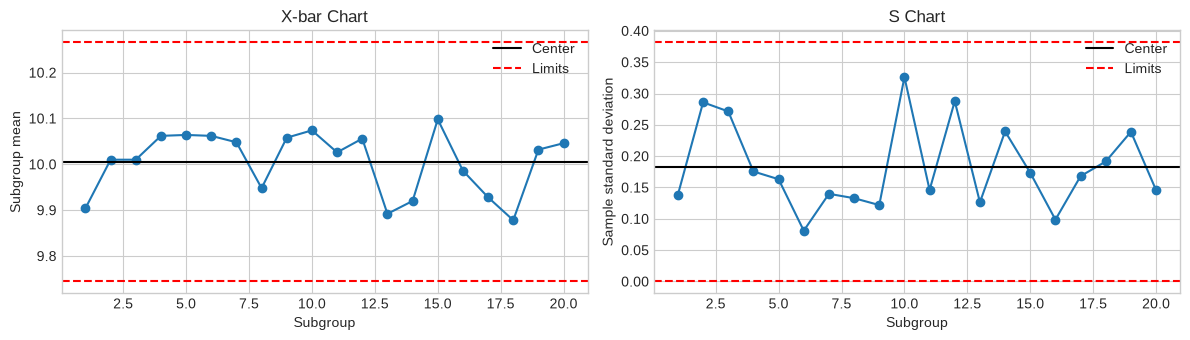

In [3]:
# 20 個 subgroup，每組五筆，共 100 點；先看數字，再看圖。
xbar_rng = np.random.default_rng(20260810)
xbar_groups = np.round(
    xbar_rng.normal(loc=10.0, scale=0.18, size=(20, 5)),
    2,
)
xbar_model = fit_xbar_s(xbar_groups)
xbar_table = apply_xbar_s(xbar_groups, xbar_model)

display(pd.DataFrame(xbar_groups, columns=["m1", "m2", "m3", "m4", "m5"]))
display(pd.Series(xbar_model, name="value").to_frame())
display(xbar_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(xbar_table["subgroup"], xbar_table["xbar"], marker="o")
axes[0].axhline(xbar_model["grand_mean"], color="black", label="Center")
axes[0].axhline(xbar_model["xbar_ucl"], color="red", linestyle="--", label="Limits")
axes[0].axhline(xbar_model["xbar_lcl"], color="red", linestyle="--")
axes[0].set(title="X-bar Chart", xlabel="Subgroup", ylabel="Subgroup mean")
axes[0].legend()
axes[1].plot(xbar_table["subgroup"], xbar_table["s"], marker="o")
axes[1].axhline(xbar_model["s_bar"], color="black", label="Center")
axes[1].axhline(xbar_model["s_ucl"], color="red", linestyle="--", label="Limits")
axes[1].axhline(xbar_model["s_lcl"], color="red", linestyle="--")
axes[1].set(title="S Chart", xlabel="Subgroup", ylabel="Sample standard deviation")
axes[1].legend()
plt.tight_layout()
plt.show()

### 3.2 I-MR 的數學

單筆 sequential measurement 沒有 subgroup standard deviation，因此使用相鄰差：

$$
MR_t=|X_t-X_{t-1}|
$$

Moving range size 為 2 時，$d_2=1.128$：

$$
\widehat{\sigma}_{MR}=\frac{\overline{MR}}{1.128}
$$

$$
UCL_X,LCL_X=\bar{X}\pm3\widehat{\sigma}_{MR}
$$

$$
CL_{MR}=\overline{MR},\qquad
UCL_{MR}=3.267\overline{MR},\qquad
LCL_{MR}=0
$$

In [4]:
def fit_i_mr(values: pd.Series, limit: float = 3.0) -> dict:
    """以 individual series 的 moving range 估計 center 與 scale。"""
    series = pd.Series(values, dtype=float).reset_index(drop=True)
    moving_range = series.diff().abs()
    center = series.mean()
    mr_bar = moving_range.dropna().mean()
    sigma_mr = mr_bar / 1.128
    return {
        "center": center,
        "mr_bar": mr_bar,
        "sigma_mr": sigma_mr,
        "i_lcl": center - limit * sigma_mr,
        "i_ucl": center + limit * sigma_mr,
        "mr_lcl": 0.0,
        "mr_ucl": 3.267 * mr_bar,
    }


def apply_i_mr(values: pd.Series, model: dict) -> pd.DataFrame:
    """顯示 individual、moving range 與兩張 chart 的 signal。"""
    series = pd.Series(values, dtype=float).reset_index(drop=True)
    result = pd.DataFrame({
        "observation": np.arange(1, len(series) + 1),
        "individual": series,
        "moving_range": series.diff().abs(),
    })
    result["i_signal"] = (
        (result["individual"] < model["i_lcl"])
        | (result["individual"] > model["i_ucl"])
    )
    result["mr_signal"] = result["moving_range"] > model["mr_ucl"]
    return result

,value
center,10.100000
mr_bar,0.268421
sigma_mr,0.237962
i_lcl,9.386114
i_ucl,10.813886
mr_lcl,0.000000
mr_ucl,0.876932


,observation,individual,moving_range,i_signal,mr_signal
0,1,10.0,NaN,False,False
1,2,10.3,0.3,False,False
2,3,9.9,0.4,False,False
3,4,10.2,0.3,False,False
4,5,10.1,0.1,False,False
5,6,10.4,0.3,False,False
6,7,10.0,0.4,False,False
7,8,10.2,0.2,False,False
8,9,9.8,0.4,False,False
9,10,10.1,0.3,False,False


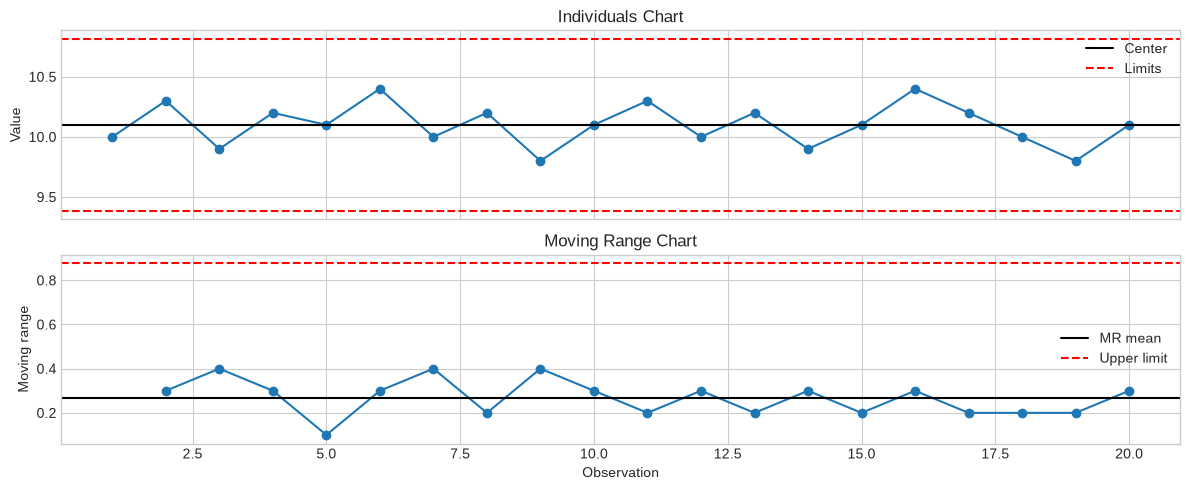

In [5]:
imr_values = pd.Series([
    10.0, 10.3, 9.9, 10.2, 10.1,
    10.4, 10.0, 10.2, 9.8, 10.1,
    10.3, 10.0, 10.2, 9.9, 10.1,
    10.4, 10.2, 10.0, 9.8, 10.1,
])
imr_model = fit_i_mr(imr_values)
imr_table = apply_i_mr(imr_values, imr_model)

display(pd.Series(imr_model, name="value").to_frame())
display(imr_table)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(imr_table["observation"], imr_table["individual"], marker="o")
axes[0].axhline(imr_model["center"], color="black", label="Center")
axes[0].axhline(imr_model["i_ucl"], color="red", linestyle="--", label="Limits")
axes[0].axhline(imr_model["i_lcl"], color="red", linestyle="--")
axes[0].set(title="Individuals Chart", ylabel="Value")
axes[0].legend()
axes[1].plot(imr_table["observation"], imr_table["moving_range"], marker="o")
axes[1].axhline(imr_model["mr_bar"], color="black", label="MR mean")
axes[1].axhline(imr_model["mr_ucl"], color="red", linestyle="--", label="Upper limit")
axes[1].set(title="Moving Range Chart", xlabel="Observation", ylabel="Moving range")
axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
reference = pd.read_csv(DATA_DIR / "lab03_reference.csv", parse_dates=["timestamp"])
scenarios = pd.read_csv(DATA_DIR / "lab03_spc_scenarios.csv", parse_dates=["timestamp"])
events = pd.read_csv(
    DATA_DIR / "lab03_spc_events.csv",
    parse_dates=["start_time", "end_time"],
)

summary = pd.DataFrame({
    "table": ["reference", "scenarios", "events"],
    "rows": [len(reference), len(scenarios), len(events)],
})
display(summary)
display(reference.groupby("split").size().rename("rows").to_frame())
display(events)

,table,rows
0,reference,12096
1,scenarios,6048
2,events,5


,rows
split,
calibrate,4032
estimate,8064


,scenario_id,event_id,event_type,start_time,end_time,description
0,S1,S1-E1,large_spike,2026-03-04 10:00:00,2026-03-04 10:00:00,單一五分鐘 large spike；三次事件彼此分離，測試即時極端值偵測。
1,S1,S1-E2,large_spike,2026-03-06 14:00:00,2026-03-06 14:00:00,單一五分鐘 large spike；三次事件彼此分離，測試即時極端值偵測。
2,S1,S1-E3,large_spike,2026-03-08 10:00:00,2026-03-08 10:00:00,單一五分鐘 large spike；三次事件彼此分離，測試即時極端值偵測。
3,S2,S2-E1,small_persistent_shift,2026-03-04 09:00:00,2026-03-05 20:55:00,持續 36 小時的小幅位移，測試跨時間累積證據。
4,S3,S3-E1,gradual_drift,2026-03-04 00:00:00,2026-03-08 23:55:00,72 小時 gradual drift 至新水準，之後維持到視窗結束。


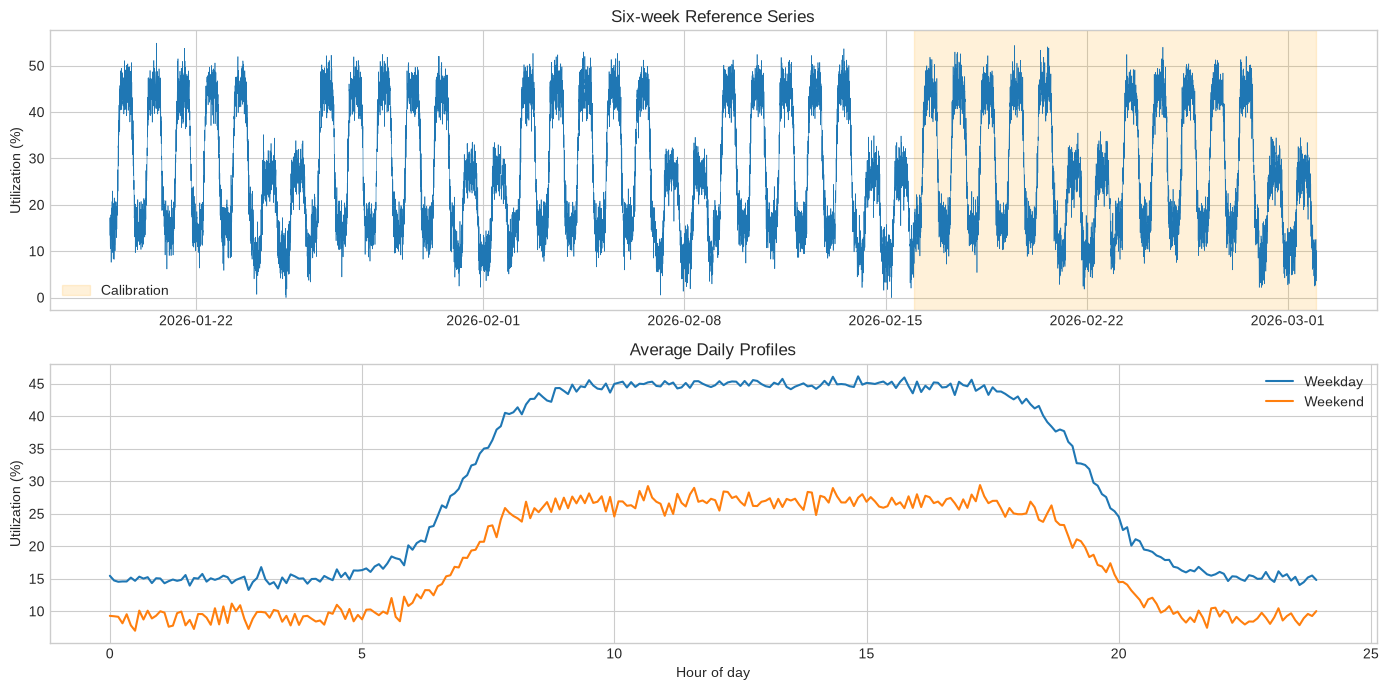

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(reference["timestamp"], reference["utilization"], linewidth=0.45)
cal_start = reference.loc[reference["split"] == "calibrate", "timestamp"].min()
axes[0].axvspan(cal_start, reference["timestamp"].max(), color="orange", alpha=0.15, label="Calibration")
axes[0].set(title="Six-week Reference Series", ylabel="Utilization (%)")
axes[0].legend()

overview = reference.assign(
    day_type=np.where(reference["timestamp"].dt.dayofweek >= 5, "Weekend", "Weekday"),
    hour=reference["timestamp"].dt.hour + reference["timestamp"].dt.minute / 60,
)
for label, frame in overview.groupby("day_type"):
    profile = frame.groupby("hour")["utilization"].mean()
    axes[1].plot(profile.index, profile.values, label=label)
axes[1].set(title="Average Daily Profiles", xlabel="Hour of day", ylabel="Utilization (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. 先移除 seasonality，再做 SPC

$$
Y_t=s_t+r_t,\qquad
r_t=Y_t-\widehat{s}_t
$$

Seasonal profile $\widehat{s}_t$ 只能用 estimate split 建立。Calibration 與 monitoring 只套用 frozen profile；否則 event 會被吸收到 baseline，形成 leakage。

我們依 weekday／weekend 與一天中的五分鐘 slot 求平均，再做一小段 circular smoothing。這不是唯一的 seasonality model，但每一步都能直接檢查。

In [8]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    """加入 weekday/weekend 與五分鐘 slot，不改原始 frame。"""
    result = frame.copy()
    result["day_type"] = np.where(
        result["timestamp"].dt.dayofweek >= 5, "weekend", "weekday"
    )
    result["slot"] = (
        result["timestamp"].dt.hour * 60 + result["timestamp"].dt.minute
    ) // CADENCE_MINUTES
    return result


def fit_seasonal_profile(estimate: pd.DataFrame, radius: int = 6) -> dict:
    """只用 estimate data 建立 weekday/weekend time-of-day profile。"""
    work = add_time_features(estimate)
    profiles = {}
    for day_type in ("weekday", "weekend"):
        raw = (
            work.loc[work["day_type"] == day_type]
            .groupby("slot")["utilization"]
            .mean()
            .reindex(range(SLOTS_PER_DAY))
            .interpolate(limit_direction="both")
            .to_numpy()
        )
        profiles[day_type] = np.mean(
            np.stack([np.roll(raw, shift) for shift in range(-radius, radius + 1)]),
            axis=0,
        )
    return profiles


def apply_seasonal_profile(frame: pd.DataFrame, profiles: dict) -> pd.Series:
    """將 frozen profile 對齊 frame timestamps。"""
    work = add_time_features(frame)
    baseline = [
        profiles[day_type][slot]
        for day_type, slot in zip(work["day_type"], work["slot"])
    ]
    return pd.Series(baseline, index=frame.index, name="baseline")


def seasonal_residual(frame: pd.DataFrame, profiles: dict) -> pd.Series:
    """回傳 raw utilization 減 frozen seasonal baseline。"""
    return frame["utilization"] - apply_seasonal_profile(frame, profiles)


estimate = reference.loc[reference["split"] == "estimate"].copy()
calibration = reference.loc[reference["split"] == "calibrate"].copy()
seasonal_model = fit_seasonal_profile(estimate)
estimate_residual = seasonal_residual(estimate, seasonal_model)
calibration_residual = seasonal_residual(calibration, seasonal_model)
residual_model = fit_i_mr(estimate_residual)

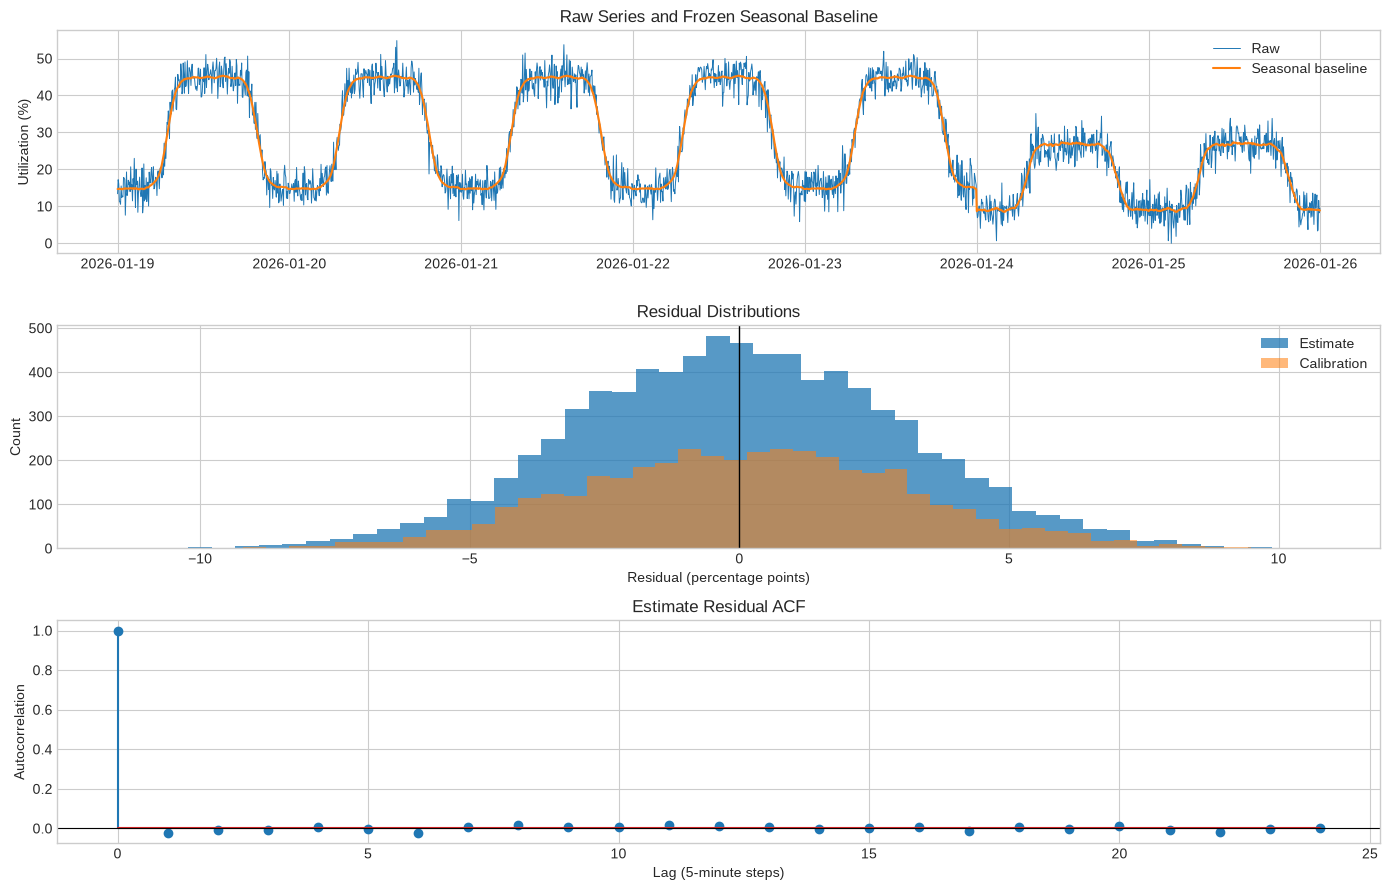

,value
estimate_residual_mean,9.868649e-17
calibration_residual_mean,9.578539e-02
sigma_mr,3.052140e+00
lag1_acf,-2.467673e-02


In [9]:
def acf_values(values: pd.Series, max_lag: int = 24) -> np.ndarray:
    """計算從 lag 0 到 max_lag 的 sample autocorrelation。"""
    series = pd.Series(values, dtype=float)
    return np.array([series.autocorr(lag=lag) for lag in range(max_lag + 1)])


sample = estimate.iloc[: 7 * SLOTS_PER_DAY].copy()
sample_baseline = apply_seasonal_profile(sample, seasonal_model)
sample_residual = sample["utilization"] - sample_baseline
acf = acf_values(estimate_residual, 24)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(sample["timestamp"], sample["utilization"], linewidth=0.7, label="Raw")
axes[0].plot(sample["timestamp"], sample_baseline, linewidth=1.5, label="Seasonal baseline")
axes[0].set(title="Raw Series and Frozen Seasonal Baseline", ylabel="Utilization (%)")
axes[0].legend()
axes[1].hist(estimate_residual, bins=50, alpha=0.75, label="Estimate")
axes[1].hist(calibration_residual, bins=50, alpha=0.55, label="Calibration")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="Residual Distributions", xlabel="Residual (percentage points)", ylabel="Count")
axes[1].legend()
axes[2].stem(np.arange(len(acf)), acf)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(title="Estimate Residual ACF", xlabel="Lag (5-minute steps)", ylabel="Autocorrelation")
plt.tight_layout()
plt.show()

display(pd.Series({
    "estimate_residual_mean": estimate_residual.mean(),
    "calibration_residual_mean": calibration_residual.mean(),
    "sigma_mr": residual_model["sigma_mr"],
    "lag1_acf": acf[1],
}, name="value").to_frame())

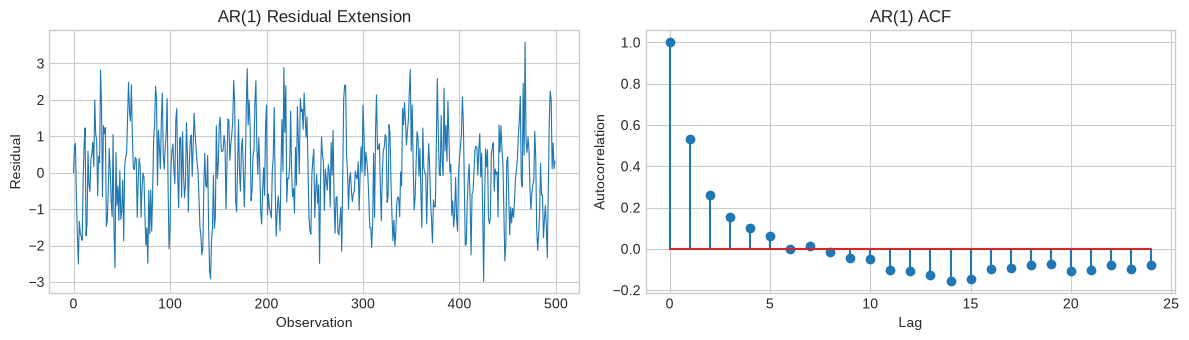

In [10]:
# 延伸：若 residual 還有 AR(1) dependence，memory detector 可能把正常相關性當成證據。
ar_rng = np.random.default_rng(20260809)
white_noise = ar_rng.normal(size=500)
ar1 = np.zeros_like(white_noise)
for position in range(1, len(ar1)):
    ar1[position] = 0.6 * ar1[position - 1] + white_noise[position]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(ar1, linewidth=0.8)
axes[0].set(title="AR(1) Residual Extension", xlabel="Observation", ylabel="Residual")
axes[1].stem(np.arange(25), acf_values(pd.Series(ar1), 24))
axes[1].set(title="AR(1) ACF", xlabel="Lag", ylabel="Autocorrelation")
plt.tight_layout()
plt.show()

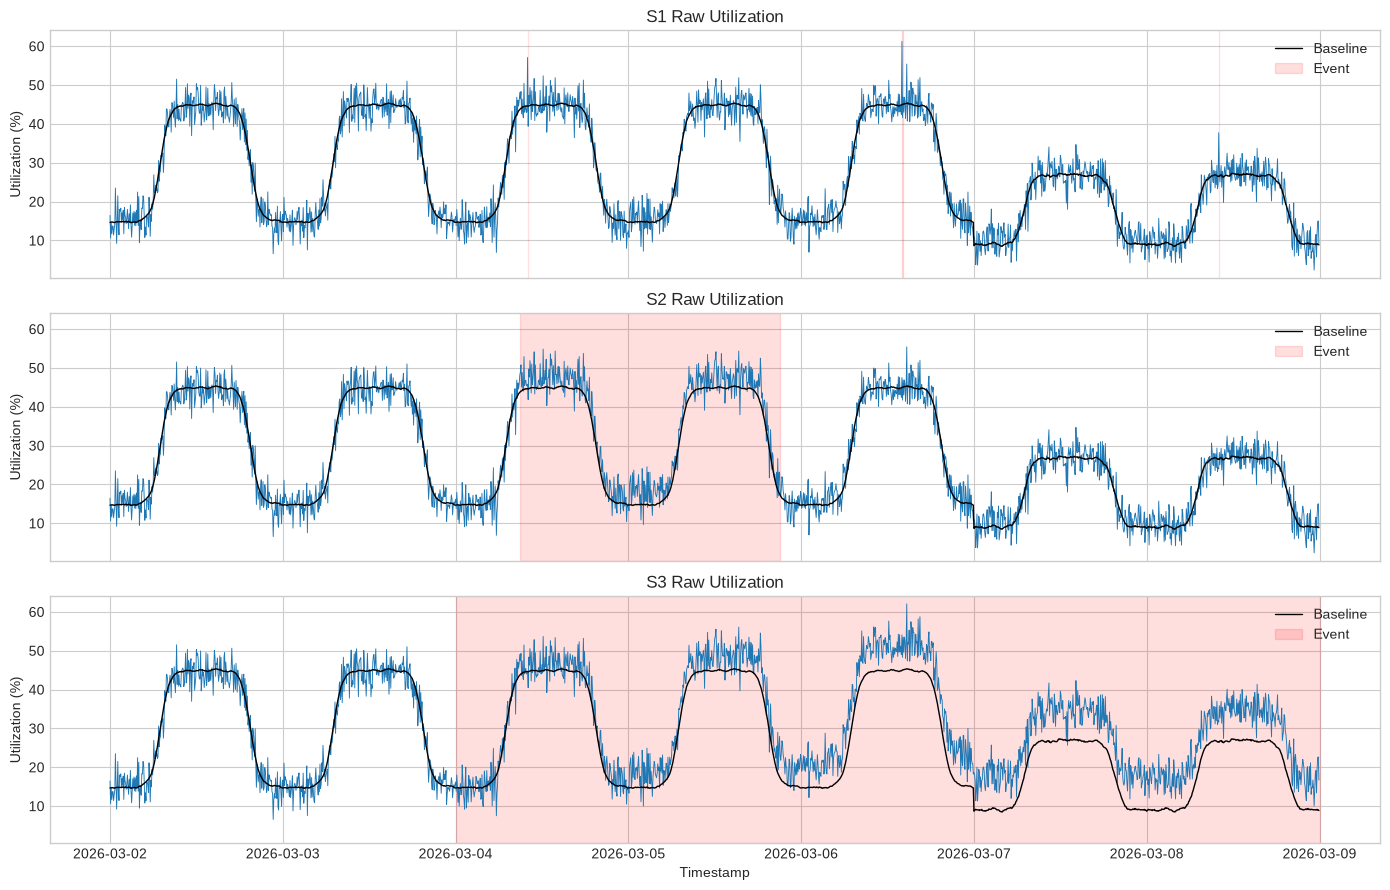

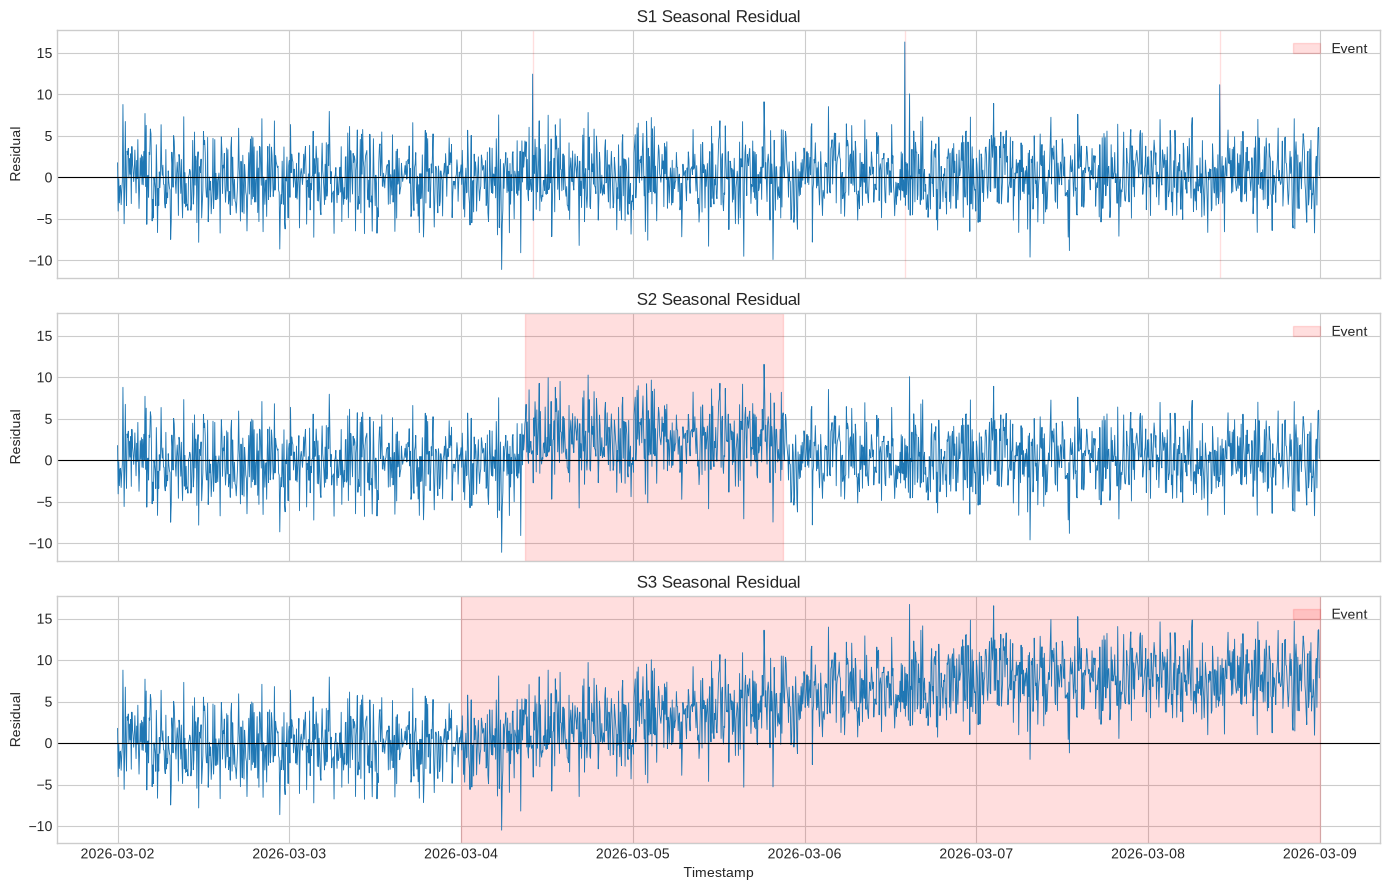

In [11]:
scenario_parts = {}
for scenario_id, frame in scenarios.groupby("scenario_id", sort=True):
    part = frame.copy().reset_index(drop=True)
    part["baseline"] = apply_seasonal_profile(part, seasonal_model)
    part["residual"] = part["utilization"] - part["baseline"]
    part["standardized_residual"] = (
        (part["residual"] - residual_model["center"])
        / residual_model["sigma_mr"]
    )
    scenario_parts[scenario_id] = part


def shade_scenario_events(axis, scenario_id: str) -> None:
    """畫出 scenario 的全部 event windows；單點事件延伸一個 cadence。"""
    rows = events.loc[events["scenario_id"] == scenario_id].sort_values("start_time")
    for event_number, (_, event) in enumerate(rows.iterrows()):
        visible_end = event["end_time"] + pd.Timedelta(minutes=CADENCE_MINUTES)
        axis.axvspan(
            event["start_time"],
            visible_end,
            color="red",
            alpha=0.13,
            label="Event" if event_number == 0 else None,
        )

raw_limits = (
    scenarios["utilization"].min() - 2,
    scenarios["utilization"].max() + 2,
)
residual_limits = (
    min(part["residual"].min() for part in scenario_parts.values()) - 1,
    max(part["residual"].max() for part in scenario_parts.values()) + 1,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)
for axis, (scenario_id, part) in zip(axes, scenario_parts.items()):
    axis.plot(part["timestamp"], part["utilization"], linewidth=0.65)
    axis.plot(part["timestamp"], part["baseline"], color="black", linewidth=1.0, label="Baseline")
    shade_scenario_events(axis, scenario_id)
    axis.set(title=f"{scenario_id} Raw Utilization", ylabel="Utilization (%)", ylim=raw_limits)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)
for axis, (scenario_id, part) in zip(axes, scenario_parts.items()):
    axis.plot(part["timestamp"], part["residual"], linewidth=0.65)
    axis.axhline(0, color="black", linewidth=0.8)
    shade_scenario_events(axis, scenario_id)
    axis.set(title=f"{scenario_id} Seasonal Residual", ylabel="Residual", ylim=residual_limits)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 5. 用 Phase I scale 表達「偏離幾個 sigma」

$$
x_t=\frac{r_t-\mu_r}{\widehat{\sigma}_{MR}}
$$

這不是 Lab04 的 feature scaling，而是 control-chart limits 原本就需要的 Phase I center 與 scale。後續三個 detector 全部使用同一條 standardized residual，避免資料表示不公平。

## 6. Shewhart：現在這一點是否極端？

$$
S_t=|x_t|,\qquad flag_t=(S_t>K)
$$

K 越小，越容易快速 signal，也會增加正常期間的 false signals。Shewhart 沒有跨時間記憶。

### ✏ 學員實驗

先用 `K_try=3.0` 執行下一格，再試 `2.5` 與 `3.5`。比較 calibration false signals/day 與 S1 score：threshold 降低後買到多少 sensitivity，又多付出多少誤報？

In [12]:
def shewhart_score(standardized: pd.Series) -> pd.Series:
    """Shewhart score 是 standardized residual 的絕對值。"""
    return pd.Series(np.abs(standardized), index=standardized.index, name="score")


def signal_onsets(flags: pd.Series) -> pd.Series:
    """只計算 False -> True；連續越界視為同一次 detector signal。"""
    boolean = pd.Series(flags, dtype=bool).reset_index(drop=True)
    return boolean & ~boolean.shift(1, fill_value=False)


def observation_days(timestamps: pd.Series) -> float:
    """將完整五分鐘時間軸換成天數。"""
    span = timestamps.max() - timestamps.min() + pd.Timedelta(minutes=CADENCE_MINUTES)
    return span / pd.Timedelta(days=1)


def false_signals_per_day(
    scores: pd.Series,
    threshold: float,
    timestamps: pd.Series,
) -> float:
    """計算正常資料中的 signal onsets/day。"""
    return signal_onsets(scores > threshold).sum() / observation_days(timestamps)

,value
K_try,3.000000
calibration_false_signals_per_day,0.571429


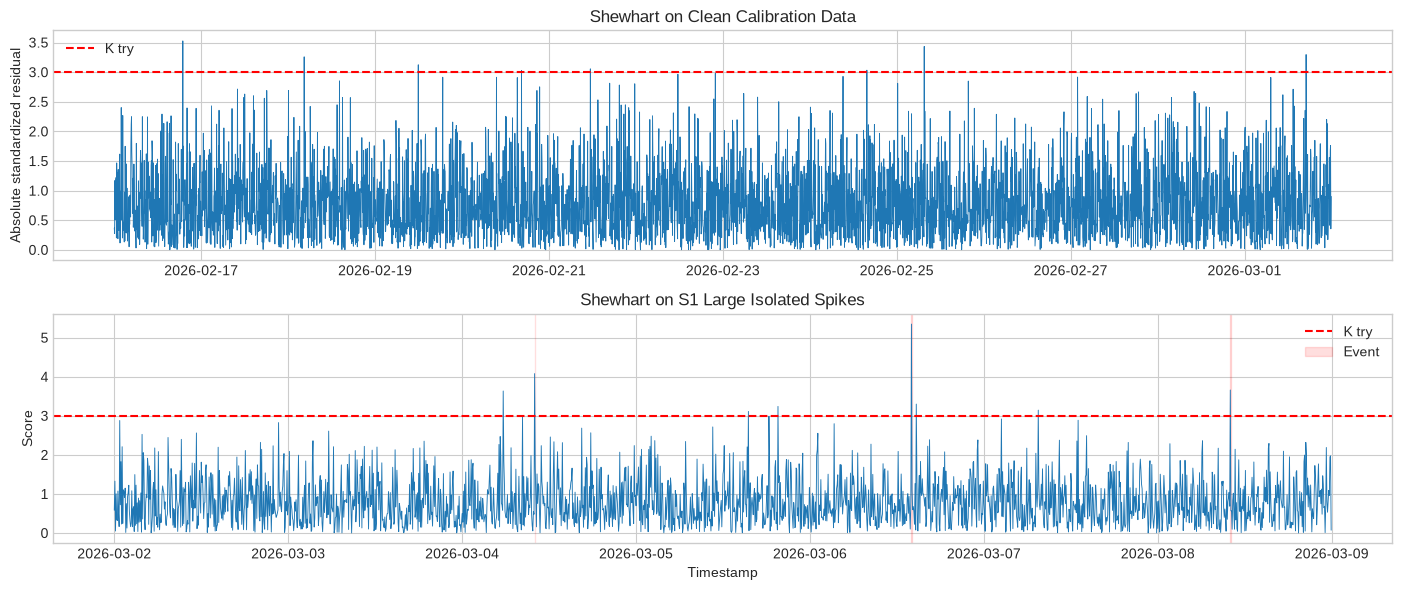

In [13]:
K_try = 3.0  # 學生實驗：降低後比較 detection delay 與 false signals。
calibration_x = (
    (calibration_residual - residual_model["center"])
    / residual_model["sigma_mr"]
).reset_index(drop=True)
calibration_shewhart = shewhart_score(calibration_x)
s1 = scenario_parts["S1"]
s1_shewhart = shewhart_score(s1["standardized_residual"])

display(pd.Series({
    "K_try": K_try,
    "calibration_false_signals_per_day": false_signals_per_day(
        calibration_shewhart, K_try, calibration["timestamp"]
    ),
}, name="value").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(calibration["timestamp"], calibration_shewhart, linewidth=0.65)
axes[0].axhline(K_try, color="red", linestyle="--", label="K try")
axes[0].set(title="Shewhart on Clean Calibration Data", ylabel="Absolute standardized residual")
axes[0].legend()
axes[1].plot(s1["timestamp"], s1_shewhart, linewidth=0.65)
axes[1].axhline(K_try, color="red", linestyle="--", label="K try")
shade_scenario_events(axes[1], "S1")
axes[1].set(title="Shewhart on S1 Large Isolated Spikes", xlabel="Timestamp", ylabel="Score")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. EWMA：最近的 process state 是否已改變？

$$
Z_t=\lambda X_t+(1-\lambda)Z_{t-1}
$$

$$
\operatorname{Var}(Z_t)=
\frac{\lambda}{2-\lambda}
\left[1-(1-\lambda)^{2t}\right]
$$

因為 $X_t$ 已 standardized，將 $|Z_t|$ 除以上式 standard deviation 後，可以用 limit multiplier $L$ 判斷：

$$
flag_t=
\left(
\frac{|Z_t|}
{\sqrt{\frac{\lambda}{2-\lambda}[1-(1-\lambda)^{2t}]}}
>L
\right)
$$

lambda 控制 memory；固定 lambda 後，L 才是 calibration threshold。

### ✏ 學員實驗

先改 `lambda_try` 比較 `0.05`、`0.20`、`0.50`，觀察 memory 長短；再把 `lambda_try` 還原為 `0.20`，只改 `L_try`。哪個參數改變 score shape，哪個只搬動 threshold？

In [14]:
def ewma_score(standardized: pd.Series, lambda_: float = 0.2) -> pd.Series:
    """回傳除以 time-varying standard deviation 的 absolute EWMA score。"""
    values = pd.Series(standardized, dtype=float).reset_index(drop=True)
    if not 0 < lambda_ <= 1:
        raise ValueError("lambda_ 必須位於 (0, 1]")
    z = np.zeros(len(values), dtype=float)
    previous = 0.0
    for position, value in enumerate(values):
        previous = lambda_ * value + (1 - lambda_) * previous
        z[position] = previous
    time = np.arange(1, len(values) + 1)
    scale = np.sqrt(
        lambda_ / (2 - lambda_)
        * (1 - (1 - lambda_) ** (2 * time))
    )
    return pd.Series(np.abs(z) / scale, index=values.index, name="score")

,value
lambda_try,0.200000
L_try,3.000000
calibration_false_signals_per_day,0.428571


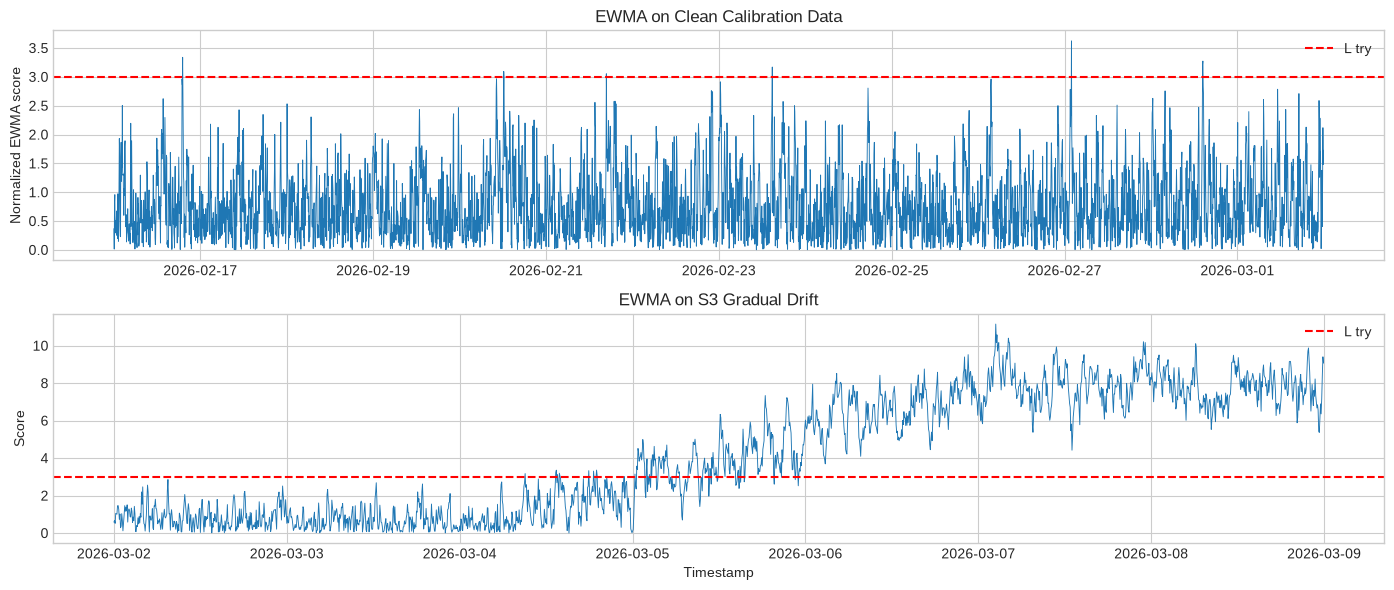

In [15]:
lambda_try = 0.20
L_try = 3.0
calibration_ewma = ewma_score(calibration_x, lambda_try)
s3 = scenario_parts["S3"]
s3_ewma = ewma_score(s3["standardized_residual"], lambda_try)

display(pd.Series({
    "lambda_try": lambda_try,
    "L_try": L_try,
    "calibration_false_signals_per_day": false_signals_per_day(
        calibration_ewma, L_try, calibration["timestamp"]
    ),
}, name="value").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(calibration["timestamp"], calibration_ewma, linewidth=0.65)
axes[0].axhline(L_try, color="red", linestyle="--", label="L try")
axes[0].set(title="EWMA on Clean Calibration Data", ylabel="Normalized EWMA score")
axes[0].legend()
axes[1].plot(s3["timestamp"], s3_ewma, linewidth=0.65)
axes[1].axhline(L_try, color="red", linestyle="--", label="L try")
axes[1].set(title="EWMA on S3 Gradual Drift", xlabel="Timestamp", ylabel="Score")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. CUSUM：是否持續累積同方向證據？

$$
C_t^+=\max(0,C_{t-1}^+ + x_t-k)
$$

$$
C_t^-=\max(0,C_{t-1}^- - x_t-k)
$$

$$
flag_t=(\max(C_t^+,C_t^-)>h)
$$

k 表達 target shift，h 表達需要累積多少證據。若目標 shift 為 $\delta\sigma$，常以 $k\approx\delta/2$ 作為起點。

### ✏ 學員實驗

先改 `k_try` 比較 `0.20`、`0.40`、`0.80`，觀察每一點能累積多少證據；再把 `k_try` 還原為 `0.40`，只改 `h_try`。哪個參數定義 target shift，哪個決定需要多少證據才開口？

In [16]:
def cusum_score(standardized: pd.Series, k: float = 0.4) -> pd.Series:
    """計算 two-sided tabular CUSUM，回傳兩方向的較大累積量。"""
    values = pd.Series(standardized, dtype=float).reset_index(drop=True)
    positive = np.zeros(len(values), dtype=float)
    negative = np.zeros(len(values), dtype=float)
    for position, value in enumerate(values):
        previous_positive = positive[position - 1] if position else 0.0
        previous_negative = negative[position - 1] if position else 0.0
        positive[position] = max(0.0, previous_positive + value - k)
        negative[position] = max(0.0, previous_negative - value - k)
    return pd.Series(np.maximum(positive, negative), name="score")

,value
k_try,0.4
h_try,5.0
calibration_false_signals_per_day,2.0


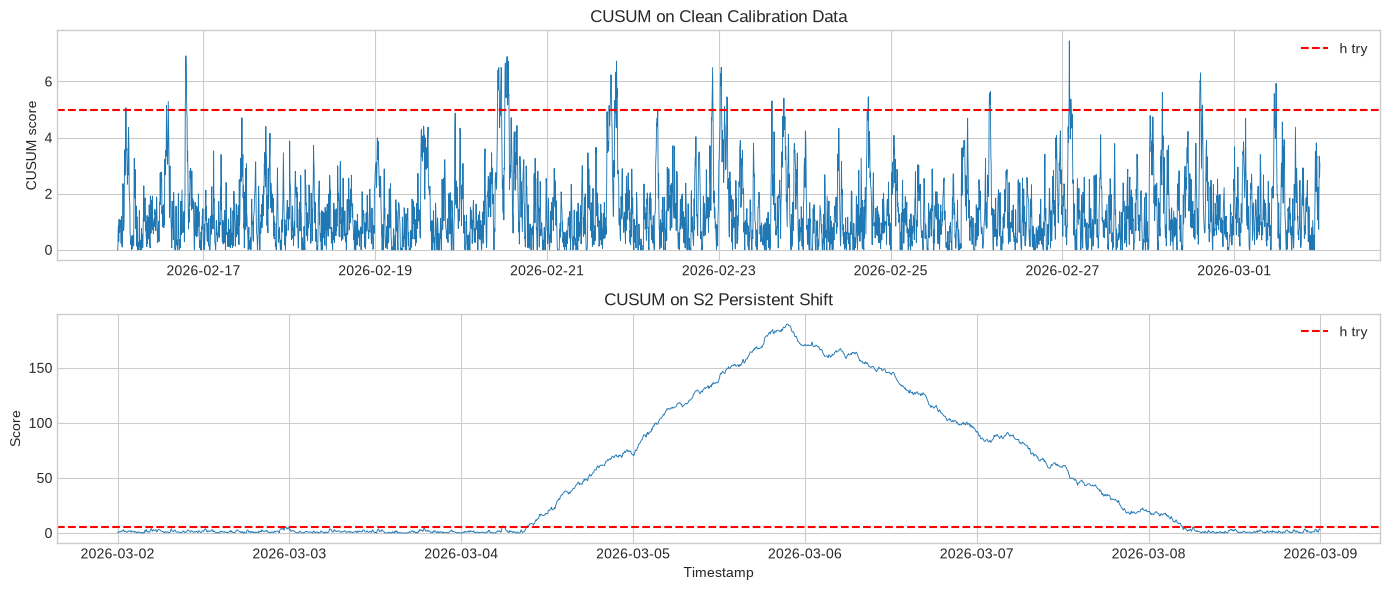

In [17]:
k_try = 0.40
h_try = 5.0
calibration_cusum = cusum_score(calibration_x, k_try)
s2 = scenario_parts["S2"]
s2_cusum = cusum_score(s2["standardized_residual"], k_try)

display(pd.Series({
    "k_try": k_try,
    "h_try": h_try,
    "calibration_false_signals_per_day": false_signals_per_day(
        calibration_cusum, h_try, calibration["timestamp"]
    ),
}, name="value").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(calibration["timestamp"], calibration_cusum, linewidth=0.65)
axes[0].axhline(h_try, color="red", linestyle="--", label="h try")
axes[0].set(title="CUSUM on Clean Calibration Data", ylabel="CUSUM score")
axes[0].legend()
axes[1].plot(s2["timestamp"], s2_cusum, linewidth=0.65)
axes[1].axhline(h_try, color="red", linestyle="--", label="h try")
axes[1].set(title="CUSUM on S2 Persistent Shift", xlabel="Timestamp", ylabel="Score")
axes[1].legend()
plt.tight_layout()
plt.show()

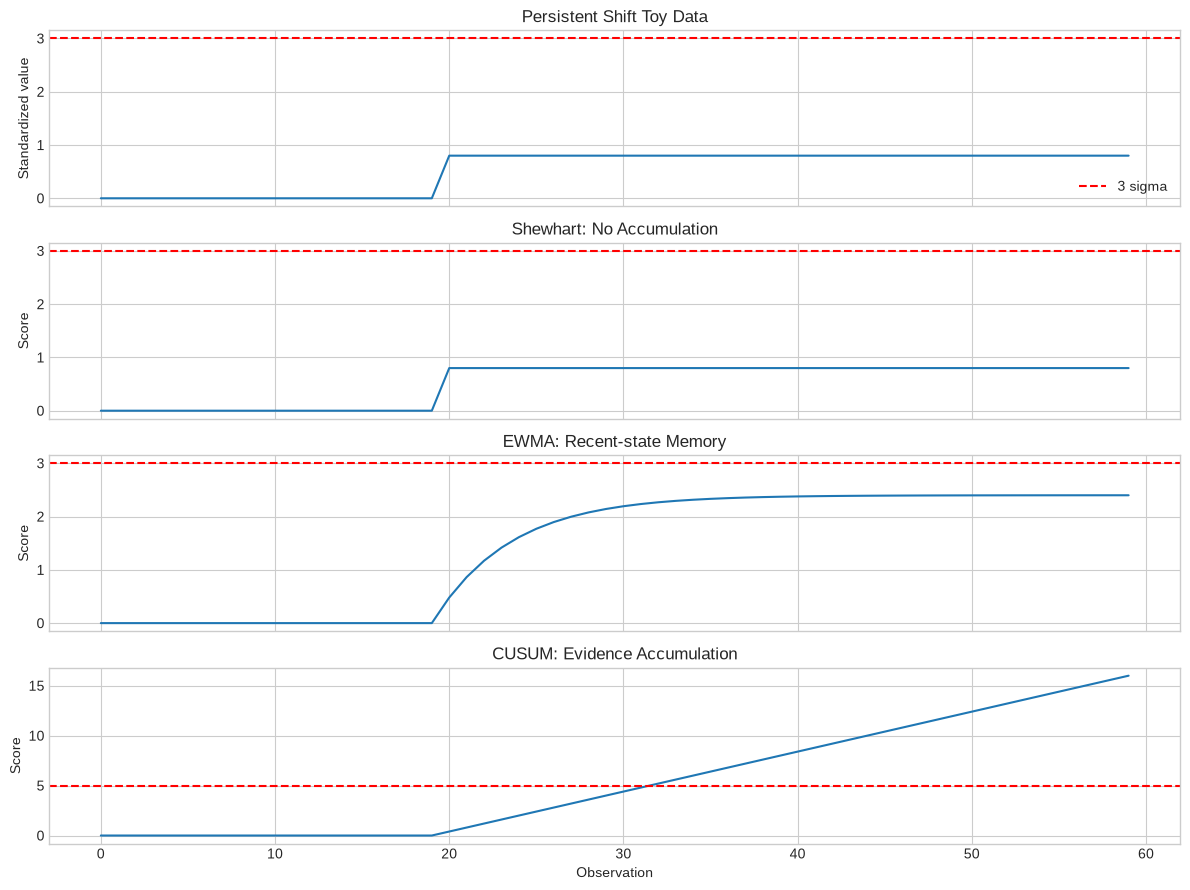

In [18]:
# 三種方法都定義後，用同一個 +0.8 sigma shift 比較 memory behavior。
toy = pd.Series(np.r_[np.zeros(20), np.full(40, 0.8)])
toy_shewhart = shewhart_score(toy)
toy_ewma = ewma_score(toy, lambda_=0.2)
toy_cusum = cusum_score(toy, k=0.4)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(toy)
axes[0].axhline(3, color="red", linestyle="--", label="3 sigma")
axes[0].set(title="Persistent Shift Toy Data", ylabel="Standardized value")
axes[0].legend()
axes[1].plot(toy_shewhart)
axes[1].axhline(3, color="red", linestyle="--")
axes[1].set(title="Shewhart: No Accumulation", ylabel="Score")
axes[2].plot(toy_ewma)
axes[2].axhline(3, color="red", linestyle="--")
axes[2].set(title="EWMA: Recent-state Memory", ylabel="Score")
axes[3].plot(toy_cusum)
axes[3].axhline(5, color="red", linestyle="--")
axes[3].set(title="CUSUM: Evidence Accumulation", xlabel="Observation", ylabel="Score")
plt.tight_layout()
plt.show()

## 9. Calibration：公平地控制 sensitivity

連續越界只算一次 detector onset：

$$
onset_t=flag_t\land\neg flag_{t-1}
$$

$$
\text{false signal onsets/day}
=\frac{\sum_t onset_t}{\text{normal calibration days}}
$$

Data v0 暫定共同 target 為每天 0.5 次。Pattern parameters（EWMA lambda、CUSUM k）先固定，再分別 calibration K、L、h。這樣最後的 delay 比較不會只是「某一個方法本來就比較容易響」。

Calibration 只有 14 天，false-signal rate 約以 $1/14=0.0714$ 次／天為步階，不一定能剛好等於 0.5。本 Lab 將 0.4–0.6 次／天視為接近目標的提示範圍。

In [19]:
def calibration_status(
    rate: float,
    close_low: float = 0.4,
    close_high: float = 0.6,
) -> str:
    """將正常期 signal rate 轉成 learner-facing calibration 狀態。"""
    if rate > close_high:
        return "too noisy"
    if rate < close_low:
        return "too quiet"
    return "close"


def summarize_calibration_attempts(
    score_map: dict[str, pd.Series],
    thresholds: dict[str, float],
    timestamps: pd.Series,
    target_per_day: float = 0.5,
    close_low: float = 0.4,
    close_high: float = 0.6,
) -> pd.DataFrame:
    """摘要 learner thresholds；只使用正常 calibration scores。"""
    if set(score_map) != set(thresholds):
        raise ValueError("score_map 與 thresholds 必須包含相同 detector")
    rows = []
    for detector, scores in score_map.items():
        threshold = float(thresholds[detector])
        if not np.isfinite(threshold) or threshold <= 0:
            raise ValueError(f"{detector} threshold 必須是大於 0 的有限數")
        rate = false_signals_per_day(scores, threshold, timestamps)
        rows.append({
            "detector": detector,
            "learner_threshold": threshold,
            "false_signals_per_day": rate,
            "target_gap": abs(rate - target_per_day),
            "status": calibration_status(rate, close_low, close_high),
        })
    return pd.DataFrame(rows)


def calibrate_threshold(
    scores: pd.Series,
    timestamps: pd.Series,
    target_per_day: float = 0.5,
) -> dict:
    """搜尋最接近 target false signal onsets/day 的 empirical threshold。"""
    values = pd.Series(scores, dtype=float).reset_index(drop=True)
    quantiles = np.linspace(0.75, 0.9995, 700)
    candidates = np.unique(np.quantile(values, quantiles))
    rows = []
    for threshold in candidates:
        rate = false_signals_per_day(values, threshold, timestamps)
        rows.append((threshold, rate, abs(rate - target_per_day)))
    table = pd.DataFrame(rows, columns=["threshold", "false_signals_per_day", "error"])
    selected = table.sort_values(
        ["error", "threshold"], ascending=[True, True]
    ).iloc[0]
    return {
        "threshold": float(selected["threshold"]),
        "false_signals_per_day": float(selected["false_signals_per_day"]),
        "target_per_day": target_per_day,
        "search_table": table,
    }


def evaluate_event(
    scores: pd.Series,
    threshold: float,
    timestamps: pd.Series,
    event: pd.Series,
) -> dict:
    """計算 event recall 與第一個 signal onset delay。"""
    onset = signal_onsets(pd.Series(scores).reset_index(drop=True) > threshold)
    time = pd.Series(timestamps).reset_index(drop=True)
    in_event = (
        onset
        & time.ge(event["start_time"])
        & time.le(event["end_time"])
    )
    if in_event.any():
        first = time.loc[in_event].iloc[0]
        delay_minutes = (first - event["start_time"]) / pd.Timedelta(minutes=1)
        result = {"event_recall": 1, "delay_minutes": float(delay_minutes)}
    else:
        result = {"event_recall": 0, "delay_minutes": np.nan}
    result["sustained_delay_minutes"] = sustained_detection_delay(
        scores,
        threshold,
        timestamps,
        event,
        run_length=3,
    )
    return result


def sustained_detection_delay(
    scores: pd.Series,
    threshold: float,
    timestamps: pd.Series,
    event: pd.Series,
    run_length: int = 3,
) -> float:
    """回傳 event 內第一段連續 signals 的起點 delay；沒有則為 NaN。"""
    flags = pd.Series(scores).reset_index(drop=True).gt(threshold)
    time = pd.Series(timestamps).reset_index(drop=True)
    confirmed = flags.rolling(run_length, min_periods=run_length).sum().eq(run_length)
    for completion_position in np.flatnonzero(confirmed.to_numpy()):
        start_position = completion_position - run_length + 1
        start_time = time.iloc[start_position]
        completion_time = time.iloc[completion_position]
        if (
            start_time >= event["start_time"]
            and completion_time <= event["end_time"]
        ):
            return float(
                (start_time - event["start_time"]) / pd.Timedelta(minutes=1)
            )
    return np.nan

### ✏ Calibration Challenge：先由你調，再看機器答案

營運目標是把三個 detector 調到約 **0.5 false signal onsets/day**。只能看 14 天 clean calibration data；不能根據 S1–S3 的 detection delay 回頭選 threshold。

- Shewhart：只調 $K$。
- EWMA：固定 $\lambda=0.2$，只調 $L$。
- CUSUM：固定 $k=0.4$，只調 $h$。
- `0.4–0.6/day` 顯示 `close`；高於範圍是 `too noisy`，低於範圍是 `too quiet`。

先執行預設值，再依狀態提高或降低 threshold。記下你的三個答案，下一格才會顯示 empirical search 的參考值。

,detector,learner_threshold,false_signals_per_day,target_gap,status
0,Shewhart,3.0,0.571429,0.071429,close
1,EWMA,3.0,0.428571,0.071429,close
2,CUSUM,5.0,2.000000,1.500000,too noisy


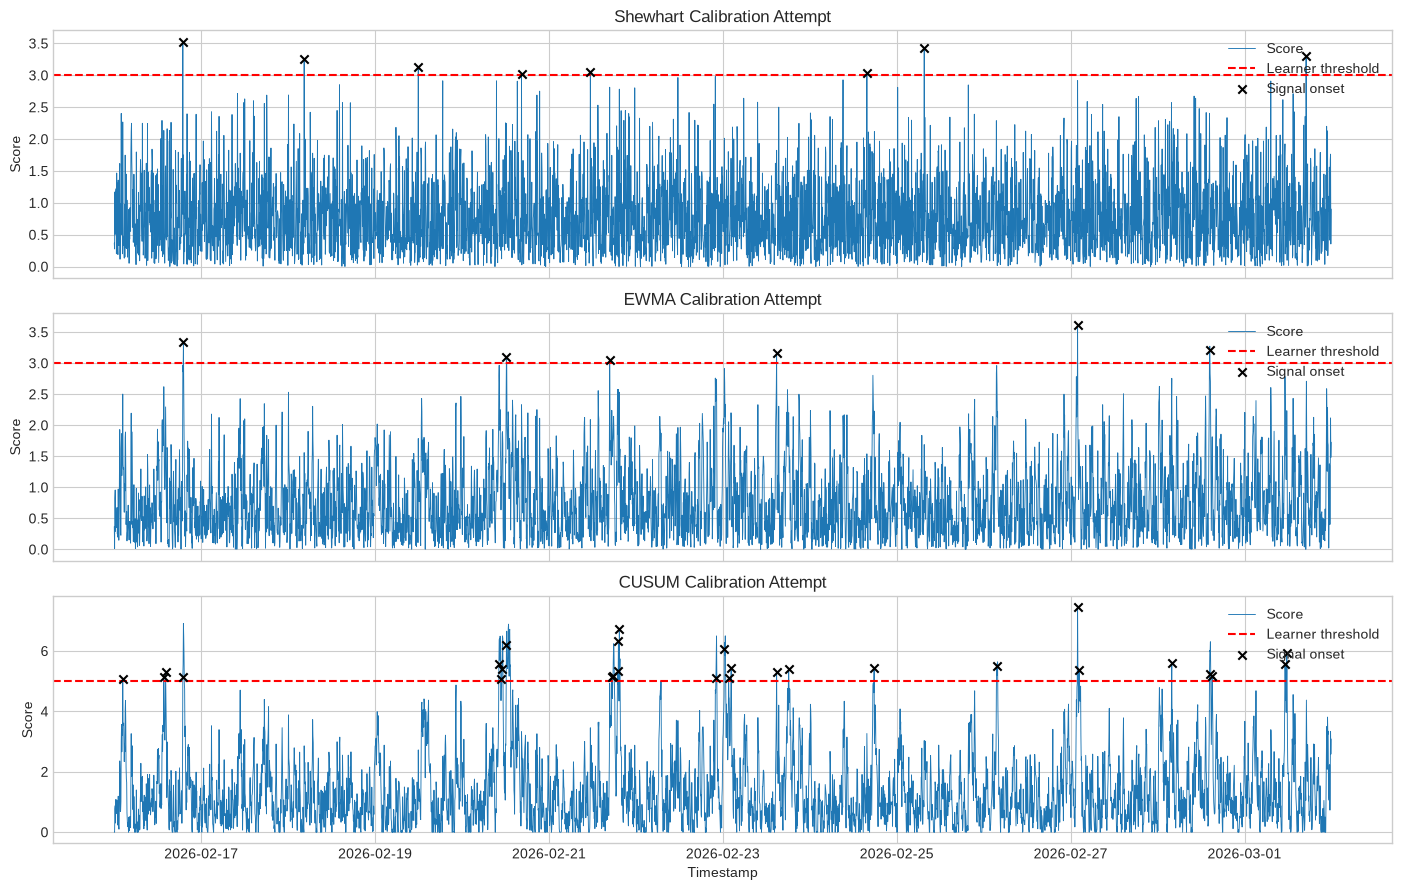

In [20]:
TARGET_FALSE_SIGNALS_PER_DAY = 0.5
LAMBDA_CANONICAL = 0.20
K_CUSUM_CANONICAL = 0.40

calibration_scores = {
    "Shewhart": shewhart_score(calibration_x),
    "EWMA": ewma_score(calibration_x, LAMBDA_CANONICAL),
    "CUSUM": cusum_score(calibration_x, K_CUSUM_CANONICAL),
}

# ✏ 只修改這三個 threshold；不要用 S1–S3 的結果反向調參。
K_try = 3.0
L_try = 3.0
h_try = 5.0
learner_thresholds = {
    "Shewhart": K_try,
    "EWMA": L_try,
    "CUSUM": h_try,
}
learner_calibration_table = summarize_calibration_attempts(
    calibration_scores,
    learner_thresholds,
    calibration["timestamp"],
    TARGET_FALSE_SIGNALS_PER_DAY,
)
display(learner_calibration_table)

calibration_time = calibration["timestamp"].reset_index(drop=True)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for axis, (detector, scores) in zip(axes, calibration_scores.items()):
    threshold = learner_thresholds[detector]
    onset = signal_onsets(scores > threshold)
    axis.plot(calibration_time, scores, linewidth=0.65, label="Score")
    axis.axhline(
        threshold,
        color="red",
        linestyle="--",
        label="Learner threshold",
    )
    axis.scatter(
        calibration_time.loc[onset],
        scores.loc[onset],
        color="black",
        marker="x",
        label="Signal onset",
        zorder=3,
    )
    axis.set(title=f"{detector} Calibration Attempt", ylabel="Score")
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [21]:
# Machine calibration 是 700 個 empirical quantile candidates 中最接近 target 的參考答案，並非唯一可部署設定。
calibrated = {
    name: calibrate_threshold(
        score,
        calibration["timestamp"],
        TARGET_FALSE_SIGNALS_PER_DAY,
    )
    for name, score in calibration_scores.items()
}
machine_calibration_table = pd.DataFrame([
    {
        "detector": name,
        "machine_threshold": result["threshold"],
        "machine_false_signals_per_day": result["false_signals_per_day"],
        "machine_target_gap": abs(
            result["false_signals_per_day"] - result["target_per_day"]
        ),
    }
    for name, result in calibrated.items()
])
calibration_comparison = (
    learner_calibration_table.rename(columns={
        "false_signals_per_day": "learner_false_signals_per_day",
        "target_gap": "learner_target_gap",
        "status": "learner_status",
    })
    .merge(machine_calibration_table, on="detector", validate="one_to_one")
)
display(calibration_comparison)

,detector,learner_threshold,learner_false_signals_per_day,learner_target_gap,learner_status,machine_threshold,machine_false_signals_per_day,machine_target_gap
0,Shewhart,3.0,0.571429,0.071429,close,3.030741,0.500000,0.000000
1,EWMA,3.0,0.428571,0.071429,close,2.962259,0.571429,0.071429
2,CUSUM,5.0,2.000000,1.500000,too noisy,6.499311,0.571429,0.071429


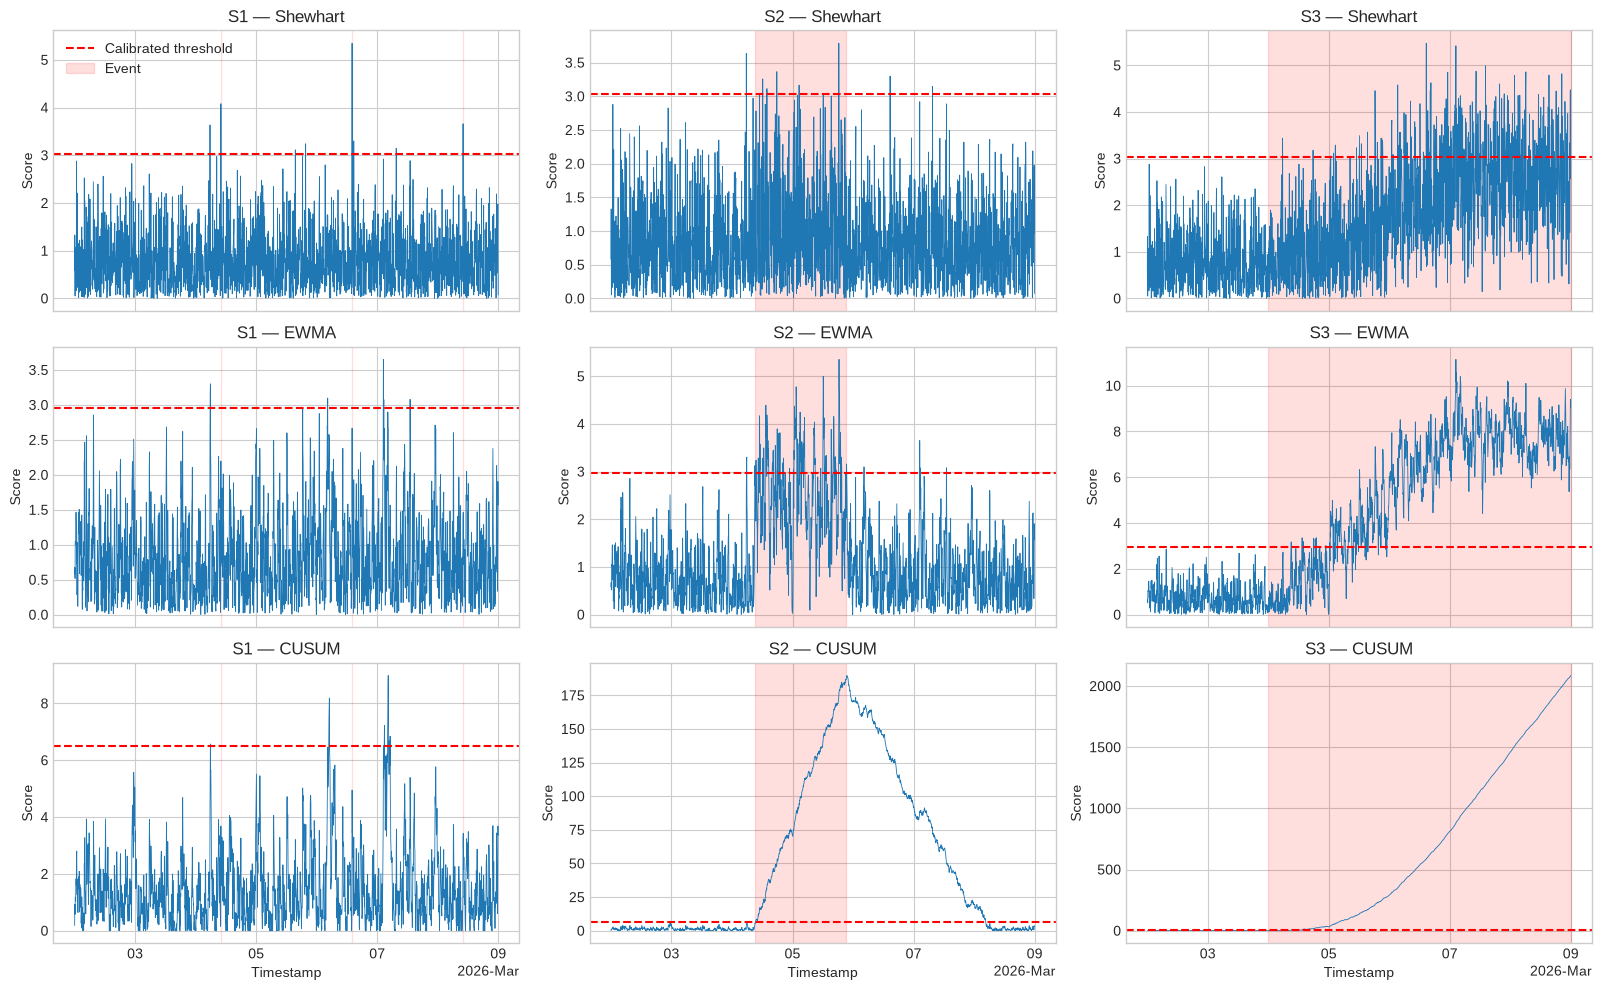

,scenario_id,event_id,detector,threshold,calibration_false_signals_per_day,event_recall,delay_minutes,sustained_delay_minutes
0,S1,S1-E1,Shewhart,3.030741,0.500000,1,0.0,NaN
1,S1,S1-E2,Shewhart,3.030741,0.500000,1,0.0,NaN
2,S1,S1-E3,Shewhart,3.030741,0.500000,1,0.0,NaN
3,S1,S1-E1,EWMA,2.962259,0.571429,0,NaN,NaN
4,S1,S1-E2,EWMA,2.962259,0.571429,0,NaN,NaN
5,S1,S1-E3,EWMA,2.962259,0.571429,0,NaN,NaN
6,S1,S1-E1,CUSUM,6.499311,0.571429,0,NaN,NaN
7,S1,S1-E2,CUSUM,6.499311,0.571429,0,NaN,NaN
8,S1,S1-E3,CUSUM,6.499311,0.571429,0,NaN,NaN
9,S2,S2-E1,Shewhart,3.030741,0.500000,1,115.0,NaN


,scenario_id,detector,event_count,events_detected,event_recall_rate,median_first_onset_delay_minutes,median_sustained_delay_minutes
0,S1,CUSUM,3,0,0.0,NaN,NaN
1,S1,EWMA,3,0,0.0,NaN,NaN
2,S1,Shewhart,3,3,1.0,0.0,NaN
3,S2,CUSUM,1,1,1.0,15.0,30.0
4,S2,EWMA,1,1,1.0,5.0,115.0
5,S2,Shewhart,1,1,1.0,115.0,NaN
6,S3,CUSUM,1,1,1.0,570.0,800.0
7,S3,EWMA,1,1,1.0,545.0,1475.0
8,S3,Shewhart,1,1,1.0,340.0,3230.0


First onset delay (minutes)  CUSUM   EWMA  Shewhart
scenario_id event_id                               
S1          S1-E1              NaN    NaN       0.0
            S1-E2              NaN    NaN       0.0
            S1-E3              NaN    NaN       0.0
S2          S2-E1             15.0    5.0     115.0
S3          S3-E1            570.0  545.0     340.0

Three-point sustained delay (minutes)  CUSUM    EWMA  Shewhart
scenario_id event_id                                          
S1          S1-E1                        NaN     NaN       NaN
            S1-E2                        NaN     NaN       NaN
            S1-E3                        NaN     NaN       NaN
S2          S2-E1                       30.0   115.0       NaN
S3          S3-E1                      800.0  1475.0    3230.0

In [22]:
def scenario_scores(part: pd.DataFrame) -> dict[str, pd.Series]:
    """以 frozen pattern parameters 計算三個 detector scores。"""
    standardized = part["standardized_residual"]
    return {
        "Shewhart": shewhart_score(standardized),
        "EWMA": ewma_score(standardized, LAMBDA_CANONICAL),
        "CUSUM": cusum_score(standardized, K_CUSUM_CANONICAL),
    }


score_rows = []
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex="col")
detector_names = ["Shewhart", "EWMA", "CUSUM"]
for column, (scenario_id, part) in enumerate(scenario_parts.items()):
    scenario_events = events.loc[
        events["scenario_id"] == scenario_id
    ].sort_values("start_time")
    score_map = scenario_scores(part)
    for row, detector in enumerate(detector_names):
        threshold = calibrated[detector]["threshold"]
        for _, event in scenario_events.iterrows():
            metrics = evaluate_event(
                score_map[detector],
                threshold,
                part["timestamp"],
                event,
            )
            score_rows.append({
                "scenario_id": scenario_id,
                "event_id": event["event_id"],
                "detector": detector,
                "threshold": threshold,
                "calibration_false_signals_per_day": calibrated[detector]["false_signals_per_day"],
                **metrics,
            })
        axis = axes[row, column]
        axis.plot(part["timestamp"], score_map[detector], linewidth=0.6)
        axis.axhline(threshold, color="red", linestyle="--", label="Calibrated threshold")
        shade_scenario_events(axis, scenario_id)
        axis.set(title=f"{scenario_id} — {detector}", ylabel="Score")
        if row == 2:
            axis.set_xlabel("Timestamp")
        if row == 0 and column == 0:
            axis.legend(loc="upper left")
    locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
    axes[-1, column].xaxis.set_major_locator(locator)
    axes[-1, column].xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
plt.tight_layout()
plt.show()

scorecard = pd.DataFrame(score_rows)
display(scorecard)

scorecard_summary = (
    scorecard.groupby(["scenario_id", "detector"], sort=True)
    .agg(
        event_count=("event_id", "count"),
        events_detected=("event_recall", "sum"),
        event_recall_rate=("event_recall", "mean"),
        median_first_onset_delay_minutes=("delay_minutes", "median"),
        median_sustained_delay_minutes=("sustained_delay_minutes", "median"),
    )
    .reset_index()
)
display(scorecard_summary)
display(
    scorecard.pivot(
        index=["scenario_id", "event_id"],
        columns="detector",
        values="delay_minutes",
    ).rename_axis(columns="First onset delay (minutes)")
)
display(
    scorecard.pivot(
        index=["scenario_id", "event_id"],
        columns="detector",
        values="sustained_delay_minutes",
    ).rename_axis(columns="Three-point sustained delay (minutes)")
)

## 10. 如何選方法？先看公平校準後的證據

| 討論線索 | 問題 |
| --- | --- |
| S1 isolated spikes | 為什麼沒有記憶的 Shewhart 能在事件第一點開口？ |
| S2 persistent shift | 首次越界與連續三點越界是否支持同一個選擇？ |
| S3 gradual drift | EWMA 與 CUSUM 的 delay 差距是否大到足以形成營運決策？ |
| normal calibration | 三種方法是否真的承擔接近的 false-signal cost？ |

CUSUM 與 EWMA 的適用範圍有重疊，沒有固定、互斥的標準答案。Threshold、pattern parameter、noise realization、autocorrelation、false-signal tolerance 與評估指標都可能改變排名。課堂以 scorecard 口頭討論，不要求填寫 recommendation table。

In [23]:
EXPECTED_MACHINE_THRESHOLDS = {
    "Shewhart": 3.030741,
    "EWMA": 2.962259,
    "CUSUM": 6.499311,
}
expected_scorecard_threshold = scorecard["detector"].map(
    {name: result["threshold"] for name, result in calibrated.items()}
)

LAB03_ACCEPTANCE = {
    "reference_rows": len(reference) == 12_096,
    "scenario_rows": len(scenarios) == 6_048,
    "event_rows": len(events) == 5,
    "events_per_scenario": events["scenario_id"].value_counts().to_dict()
        == {"S1": 3, "S2": 1, "S3": 1},
    "scenario_ids": set(scenarios["scenario_id"]) == {"S1", "S2", "S3"},
    "phase_split": reference["split"].value_counts().to_dict()
        == {"estimate": 8_064, "calibrate": 4_032},
    "no_embedded_labels": not any(
        "label" in column.lower() for column in scenarios.columns
    ),
    "finite_sigma_mr": np.isfinite(residual_model["sigma_mr"])
        and residual_model["sigma_mr"] > 0,
    "calibrated_detectors": set(calibrated) == {"Shewhart", "EWMA", "CUSUM"},
    "learner_calibration_rows": len(learner_calibration_table) == 3,
    "learner_calibration_columns": set(learner_calibration_table.columns) == {
        "detector",
        "learner_threshold",
        "false_signals_per_day",
        "target_gap",
        "status",
    },
    "learner_status_values": set(learner_calibration_table["status"]).issubset(
        {"too noisy", "close", "too quiet"}
    ),
    "machine_thresholds_unchanged": all(
        np.isclose(
            calibrated[name]["threshold"],
            expected,
            rtol=0.0,
            atol=1e-5,
        )
        for name, expected in EXPECTED_MACHINE_THRESHOLDS.items()
    ),
    "scorecard_uses_machine_thresholds": np.allclose(
        scorecard["threshold"],
        expected_scorecard_threshold,
        rtol=0.0,
        atol=1e-12,
    ),
}
assert all(LAB03_ACCEPTANCE.values()), LAB03_ACCEPTANCE
display(pd.Series(LAB03_ACCEPTANCE, name="passed").to_frame())

,passed
reference_rows,True
scenario_rows,True
event_rows,True
events_per_scenario,True
scenario_ids,True
phase_split,True
no_embedded_labels,True
finite_sigma_mr,True
calibrated_detectors,True
learner_calibration_rows,True


## 11. 結論與 Data v0 Review

Detector 的選擇必須先對齊正常期 false-signal cost，再比較 event recall 與 delay。

- Shewhart 沒有記憶，S1 顯示它對 isolated extreme 的即時優勢。
- EWMA 與 CUSUM 都能跨時間保留證據，適用範圍有重疊。
- CUSUM／EWMA 的排名會受 threshold、pattern parameter、noise realization、autocorrelation 與評估指標影響。

目前 amplitude、seed 與 canonical parameters 都是 **Data v0**。這份單一 deterministic simulation 能支持課堂比較，不能推出 universal ranking；請引用相同 false-signal budget 下的實際 scorecard，而不是只憑方法名稱選擇。

## 12. 延伸：替 Shewhart 加入簡單記憶的 Run Rules

看到 Shewhart 無法穩定抓到 small shift，可能會問：加入 run／zone rules，是否就不需要 EWMA 或 CUSUM？

Run Rules 確實能檢查連續多點的位置，例如連續 $n$ 點位於 center 同一側，因而捕捉部分 small shifts。但它累積的是離散條件「有沒有符合規則」；EWMA 與 CUSUM 則持續使用每一點偏移的方向與幅度。

- $n$ 太小會增加 false signals，$n$ 太大會增加 delay。
- 同時使用多條 rules 會產生 multiple-rule false signals。
- Autocorrelation 會讓連續同側更常自然發生。
- 若把某組 Run Rules 當成第四個 detector，也必須在相同 normal calibration data 上控制 false-signal budget。

因此 Run Rules 是容易加在既有 Shewhart chart 上的實用延伸，但不全面取代 EWMA／CUSUM。本 Lab 保留它作最後補充，不放入 canonical 三方法 scorecard。

In [24]:
def same_side_run(standardized: pd.Series, run_length: int = 8) -> pd.Series:
    """標記連續 run_length 點位於 center 同一側的完成位置。"""
    values = pd.Series(standardized, dtype=float).reset_index(drop=True)
    positive = values.gt(0).rolling(run_length).sum().eq(run_length)
    negative = values.lt(0).rolling(run_length).sum().eq(run_length)
    return (positive | negative).fillna(False)


run_length_try = 8
display(pd.Series({
    "run_length_try": run_length_try,
    "calibration_run_signals": signal_onsets(
        same_side_run(calibration_x, run_length_try)
    ).sum(),
}, name="value").to_frame())

,value
run_length_try,8
calibration_run_signals,15
